<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [115]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

2.11.0
Using device: cpu


## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [116]:
# 1. Get data
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# Make the image folder if it doesn't exist or is empty
if image_path.is_dir() and len(list(image_path.glob("*/*/*.jpg"))) > 0:
    print("Directory exists and contains images")
else:
    print("Did not find image data, downloading and extracting...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download the pizza dataset
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip the pizza dataset
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

Directory exists and contains images


In [117]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [118]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

print(train_dir, test_dir)

data/pizza_steak_sushi/train data/pizza_steak_sushi/test


Random image path: data/pizza_steak_sushi/test/pizza/1925494.jpg
Image class: pizza
Image height: 512
Image width: 512


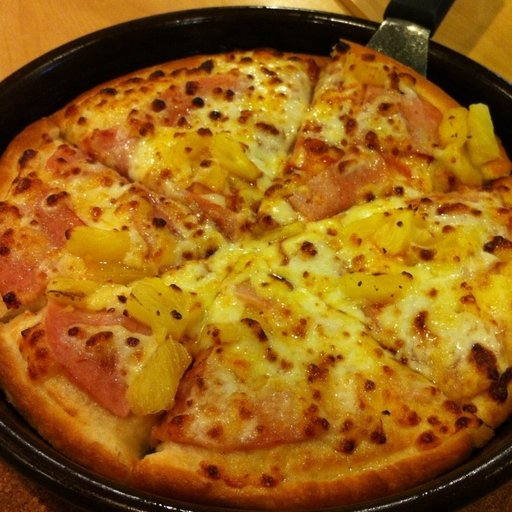

In [119]:
# Visualize an image
import random
from PIL import Image

random.seed(22)

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

In [120]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

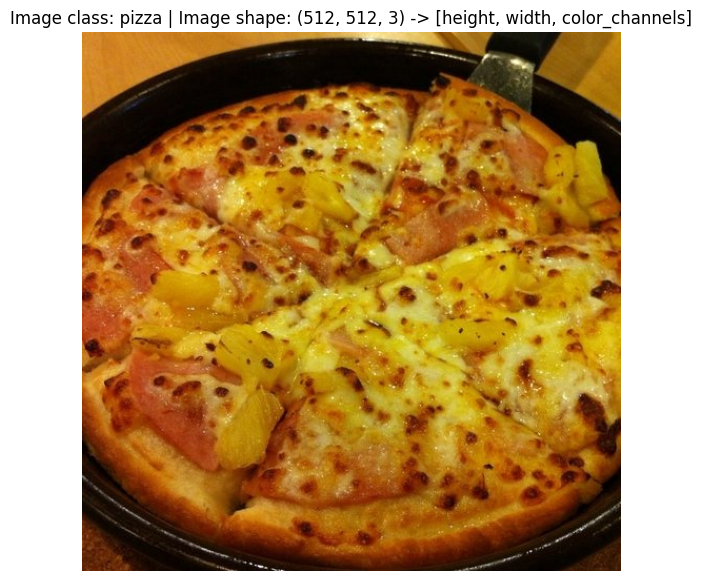

In [121]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)


### IMPORT THIS IS HOW YOU TRANSFORM FROM IMAGES -> SAME SIZE -> Datasets -> Dataloader


We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [122]:
# 3.1 Transforming data with torchvision.transforms
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform = transforms.Compose([

    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

print(data_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)


In [123]:
# Write transform for turning images into tensors
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None
)

test_data = datasets.ImageFolder(root=test_dir, 
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")


Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [124]:
# Write a function to plot transformed images


### Load image data using `ImageFolder`

In [125]:
# Use ImageFolder to create dataset(s)


In [126]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [127]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [128]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [129]:
# Turn train and test Datasets into DataLoaders

train_dataloaders = DataLoader(
    dataset=train_data, 
    batch_size=1,
    num_workers=1,
    shuffle=True
)

test_dataloaders = DataLoader(
    dataset=test_data, 
    batch_size=1,
    num_workers=1,
    shuffle=False
)

train_dataloaders, test_dataloaders

(<torch.utils.data.dataloader.DataLoader at 0x158bbbce0>,
 <torch.utils.data.dataloader.DataLoader at 0x158bbbf00>)

In [130]:
# How many batches of images are in our data loaders?

img, label = next(iter(train_dataloaders))

print(img.shape, label.shape)

torch.Size([1, 3, 64, 64]) torch.Size([1])


## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [131]:
class TinyVGG(nn.Module):

    def __init__(self, input, hidden, output):

        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input, 
                out_channels=hidden, 
                kernel_size=3, 
                stride=1, 
                padding=1
                ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden, 
                out_channels=hidden, 
                kernel_size=3, 
                stride=1, 
                padding=1
                ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden, 
                out_channels=hidden, 
                kernel_size=3, 
                padding=1
                ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden, 
                out_channels=hidden, 
                kernel_size=3, 
                padding=1
                ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden * 16 * 16,
                out_features=output
            )
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)

        return x

    

In [132]:
torch.manual_seed(42)
model0 = TinyVGG(input=3, hidden=10, output=len(train_data.classes)).to(device)


In [133]:
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

# MNIST has 10 classes
acc_fn = Accuracy(task="multiclass", num_classes=len(train_data.classes)).to(device)
acc_fn

MulticlassAccuracy()

## 4. Create training and testing functions for `model_0`.

In [134]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  for X, y in dataloader:

    X, y = X.to(device), y.to(device)
    # 1. Forward pass
    y_pred = model(X)
    
    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item() # Change to .item() maybe
    train_acc += acc_fn(y_pred.argmax(dim=1), y).item()

    # 3. Optimizer zero grad 
    optimizer.zero_grad()

    # 4. Loss backward 
    loss.backward()

    # 5. Optimizer step
    optimizer.step()
    

    # Calculate and accumualte accuracy metric across all batches
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  # Adjust metrics to get average loss and average accuracy per batch

  return train_loss, train_acc
  

In [135]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  
  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    
    for X, y in dataloader:

      X, y = X.to(device), y.to(device)
      # 1. Forward pass
      y_pred = model(X)
      
      # 2. Calculate and accumulate loss
      loss = loss_fn(y_pred, y)
      test_loss += loss.item() # Change to .item() maybe
      test_acc += acc_fn(y_pred.argmax(dim=1), y).item()

      # Calculate and accumualte accuracy metric across all batches
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    # Adjust metrics to get average loss and average accuracy per batch
  
  return  test_loss, test_acc

In [136]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model, 
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    
    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer. 

In [137]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model0 = TinyVGG(input=3, hidden=10, output=len(train_data.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model0.parameters(), 
                             lr=0.001)

model_0_results_5_epochs = train(
    model=model0,
    train_dataloader=train_dataloaders,
    test_dataloader=test_dataloaders,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=5
)

model_0_results_5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1177 | train_acc: 0.2978 | test_loss: 1.0970 | test_acc: 0.3333
Epoch: 2 | train_loss: 1.0999 | train_acc: 0.2889 | test_loss: 1.0994 | test_acc: 0.2533
Epoch: 3 | train_loss: 1.0992 | train_acc: 0.3200 | test_loss: 1.0996 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.0991 | train_acc: 0.3244 | test_loss: 1.0998 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.0989 | train_acc: 0.3289 | test_loss: 1.1002 | test_acc: 0.3333


{'train_loss': [1.1176603203349644,
  1.0998689158757529,
  1.0991766860749987,
  1.0990826898150974,
  1.0988909996880425],
 'train_acc': [0.29777777777777775,
  0.28888888888888886,
  0.32,
  0.3244444444444444,
  0.3288888888888889],
 'test_loss': [1.0970050684611004,
  1.0993589607874552,
  1.0996107069651286,
  1.099829184214274,
  1.100186653137207],
 'test_acc': [0.3333333333333333,
  0.25333333333333335,
  0.3333333333333333,
  0.3333333333333333,
  0.3333333333333333]}

In [138]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model0 = TinyVGG(input=3, hidden=10, output=len(train_data.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model0.parameters(), 
                             lr=0.001)

model_0_results_20_epochs = train(
    model=model0,
    train_dataloader=train_dataloaders,
    test_dataloader=test_dataloaders,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=20
)

model_0_results_20_epochs


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model0 = TinyVGG(input=3, hidden=10, output=len(train_data.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model0.parameters(), 
                             lr=0.001)

model_0_results_50_epochs = train(
    model=model0,
    train_dataloader=train_dataloaders,
    test_dataloader=test_dataloaders,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=50
)

model_0_results_50_epochs


### Compare different batch sizes

A smaller batch size creates more batches per epoch and more optimizer updates. A larger batch size creates fewer batches per epoch and fewer optimizer updates. This comparison trains a fresh `TinyVGG` for each batch size so the results are easier to compare.


In [ ]:
# Compare a few batch sizes using fresh models
BATCH_SIZES = [1, 16, 32]
EPOCHS = 5

def make_dataloaders(batch_size: int):
    train_dataloader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        num_workers=1,
        shuffle=True
    )
    test_dataloader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        num_workers=1,
        shuffle=False
    )
    return train_dataloader, test_dataloader

batch_size_comparison = []

for batch_size in BATCH_SIZES:
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)

    train_dl, test_dl = make_dataloaders(batch_size=batch_size)
    comparison_model = TinyVGG(input=3, hidden=10, output=len(train_data.classes)).to(device)
    comparison_loss_fn = nn.CrossEntropyLoss()
    comparison_optimizer = torch.optim.Adam(params=comparison_model.parameters(), lr=0.001)

    print(f"\nTraining with batch_size={batch_size}")
    results = train(
        model=comparison_model,
        train_dataloader=train_dl,
        test_dataloader=test_dl,
        optimizer=comparison_optimizer,
        loss_fn=comparison_loss_fn,
        epochs=EPOCHS
    )

    batch_size_comparison.append({
        "batch_size": batch_size,
        "train_batches_per_epoch": len(train_dl),
        "test_batches_per_epoch": len(test_dl),
        "final_train_loss": results["train_loss"][-1],
        "final_train_acc": results["train_acc"][-1],
        "final_test_loss": results["test_loss"][-1],
        "final_test_acc": results["test_acc"][-1]
    })

batch_size_comparison


It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [ ]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)


It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [ ]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...") 
    zip_ref.extractall(image_path)

data/pizza_steak_sushi_20_percent directory exists.
Unzipping pizza, steak, sushi 20% data...


In [ ]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.


Excellent, we now have double the training and testing images... 

In [ ]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [ ]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((64, 64)),                                     
  transforms.ToTensor()
])

# Create datasets


# Create dataloaders


In [ ]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction. 
* Does the model you trained in exercise 7 get it right? 
* If not, what do you think you could do to improve it?